Resuleve sistema de primer orden.  
Sistema masa y amortiguador. 

$$\frac{dv}{dt} = -\frac{c}{M}v+\frac{1}{M}u\$$




In [12]:
# Codigo de Python
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del sistema
M = 40 #Kg
c = 0.5 # N.s/m

# Entrada
u = 0

# Datos de simulacion
# Discretizacion del tiempo
Tsim = 400 #segundos
h = 50 # segundos
t = np.arange(0,Tsim+h,h)
n = len(t)

# Condiciones iniciales
v0 = 1 #m/s

# solucion analitica
v_real = v0*np.exp(-c/M*t)


# Formulas de Métodos Numéricos  
Llevar la ecuación diferencial a la siguiente forma: $$\frac{dx}{dt}=f(t,x)$$

## Euler
$$x_{i+1} = x_i + h*f(t_i,x_i)$$

In [13]:
# vector de la variable de velocidad
v = np.zeros(n)
v[0] = v0

# solucion con euler
for i in range(len(t)-1):
    v[i+1] = v[i] + h * (-c/M*v[i] + 1/M*u)

## Heun - RK1/2
$$x_{i+1} = x_i + h(\frac{1}{2}k_1+\frac{1}{2}k_2) $$
Dónde:  
$\hspace{1cm} k_1 = f(t_i,x_i) $  
$\hspace{1cm} k_2 = f(t_i+h,x_i+h*k_1) $ 

In [14]:
v_heun = np.zeros(len(t))
v_heun[0] = v0
# solucion con Heun
for i in range(len(t)-1):
    pendiente1 = (-c/M*v_heun[i] + 1/M*u)
    vtemp = v_heun[i] + h * pendiente1
    pendiente2 =  (-c/M*vtemp + 1/M*u)
    v_heun[i+1] = v_heun[i] + h * (pendiente1+pendiente2)/2

## Ralston - RK2/3
$$x_{i+1} = x_i + h(\frac{1}{3}k_1+\frac{2}{3}k_2) $$
Dónde:  
$\hspace{1cm} k_1 = f(t_i,x_i) $  
$\hspace{1cm} k_2 = f(t_i+\frac{3}{4}h,x_i+\frac{3}{4}h*k_1) $  

In [15]:
# Declaracion de funciones en python
def f(t,x):
    # x es la velocidad en la ecuaciòn original
    return -c/M*x + 1/M * u 

# Ralston
v_ralston = np.zeros(len(t))
v_ralston[0] = v0

for i in range(len(t)-1):
    k1 = f(t[i],v_ralston[i])
    k2 = f(t[i]+3/4*h,v_ralston[i]+3/4*h*k1)
    v_ralston[i+1] = v_ralston[i] + h*(1/3*k1+2/3*k2)


In [16]:
f(0,1)

-0.0125

## Runge Kutta de Cuarto Orden
$$x_{i+1} = x_i + \frac{1}{6}h(k_1+2k_2+2k_3+k4) $$
Dónde:  
$\hspace{1cm} k_1 = f(t_i,x_i) $  
$\hspace{1cm} k_2 = f(t_i+\frac{1}{2}h,x_i+\frac{1}{2}h*k_1) $  
$\hspace{1cm} k_3 = f(t_i+\frac{1}{2}h,x_i+\frac{1}{2}h*k_2) $  
$\hspace{1cm} k_4 = f(t_i+h,x_i+h*k_3) $  

In [22]:
v_rk4 = np.zeros(len(t))
v_rk4[0] = v0
for i in range(len(t)-1):
    k1 = f(t[i],v_rk4[i])
    ttemp = t[i]+1/2*h
    xtemp = v_rk4[i]+1/2*h*k1
    k2 = f(ttemp,xtemp)
    ttemp = t[i]+1/2*h
    xtemp = v_rk4[i]+1/2*h*k2
    k3 = f(ttemp,xtemp)
    ttemp = t[i]+h
    xtemp = v_rk4[i]+h*k3
    k4 = f(ttemp,xtemp)
    v_rk4[i+1] = v_rk4[i] + 1/6*h*(k1+2*k2+2*k3+k4)

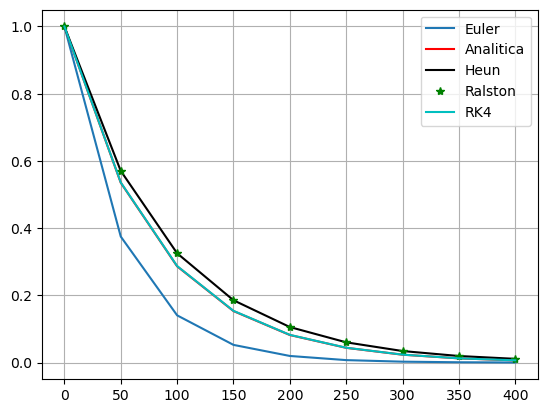

In [23]:
# gràfico
plt.plot(t,v)
plt.plot(t,v_real,'r')
plt.plot(t,v_heun,'k')
plt.plot(t,v_ralston,'*g')
plt.plot(t,v_rk4,'c')
plt.grid('on')
plt.legend(['Euler','Analitica','Heun','Ralston','RK4'])